# making plots for the grid experiment with different filters

In [3]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import os

expFolder = "data3_grid_10Jun26"
base = Path.home() / "projects" / "metamers" / "hueSensor" / expFolder
files = os.listdir(base)
print(files)

['solid_F.txt', 'flash_NF.txt', 'solid_Or.txt', 'flash_F.txt', 'solid_NF.txt', 'flash_Or.txt']


In [12]:
def parse_filename(fname):
    name = fname.replace(".txt", "")
    condition, filt = name.split("_")
    return condition, filt

def load_grid_data(base):
    data = {}

    for fname in os.listdir(base):
        if not fname.endswith(".txt"):
            continue

        condition, filt = parse_filename(fname)
        df = pd.read_csv(Path(base) / fname, sep="\t", header=0)

        # Extract only RGB columns
        rgb = df[["HueR", "HueG", "HueB"]].copy()

        if condition not in data:
            data[condition] = {}

        data[condition][filt] = rgb

    return data

FILTER_ORDER = ["NF", "F", "Or"]   # enforce consistent ordering
def plot_condition_rgb(data, condition):
    """
    Creates a standalone figure for one condition (solid or flash),
    with 3 rows (F, NF, Or), each showing RGB traces.
    """

    filters = FILTER_ORDER

    fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

    # Compute y-limits for this condition across all filters
    row_min, row_max = np.inf, -np.inf
    for filt in filters:
        df = data[condition][filt]
        row_min = min(row_min, df[["HueR","HueG","HueB"]].min().min())
        row_max = max(row_max, df[["HueR","HueG","HueB"]].max().max())

    # Plot each filter in its own row
    for row, filt in enumerate(filters):
        ax = axes[row]
        df = data[condition][filt]

        ax.plot(df["HueR"], color="red", label="R")
        ax.plot(df["HueG"], color="green", label="G")
        ax.plot(df["HueB"], color="blue", label="B")

        ax.set_ylim(row_min, row_max)
        ax.set_title(f"{condition} — {filt}")
        ax.set_ylabel("Value")

    # One legend for the whole figure
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right")

    plt.tight_layout()
    plt.show()

FILTER_COLORS = {
    "F": "blue",      # yellow filter
    "NF": "black",    # no filter
    "Or": "orange"    # orange filter
}

CHANNELS = {
    "HueR": "Red",
    "HueG": "Green",
    "HueB": "Blue"
}

def plot_condition_by_channel(data, condition):
    """
    Creates a standalone figure for one condition (solid or flash),
    with 3 rows (R, G, B), each showing the 3 filters overlaid.
    """

    filters = FILTER_ORDER
    channels = list(CHANNELS.keys())

    fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

    # Compute y-limits across all filters and channels for this condition
    row_min, row_max = np.inf, -np.inf
    for filt in filters:
        df = data[condition][filt]
        row_min = min(row_min, df[channels].min().min())
        row_max = max(row_max, df[channels].max().max())

    # Plot each channel in its own row
    for row, ch in enumerate(channels):
        ax = axes[row]

        for filt in filters:
            df = data[condition][filt]
            ax.plot(df[ch], color=FILTER_COLORS[filt], label=filt, linewidth=1.4)

        ax.set_ylim(row_min, row_max)
        ax.set_title(f"{condition} — {CHANNELS[ch]}")
        ax.set_ylabel("Value")

    # One legend for the whole figure
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right")

    plt.tight_layout()
    plt.show()
    
data = load_grid_data(base)


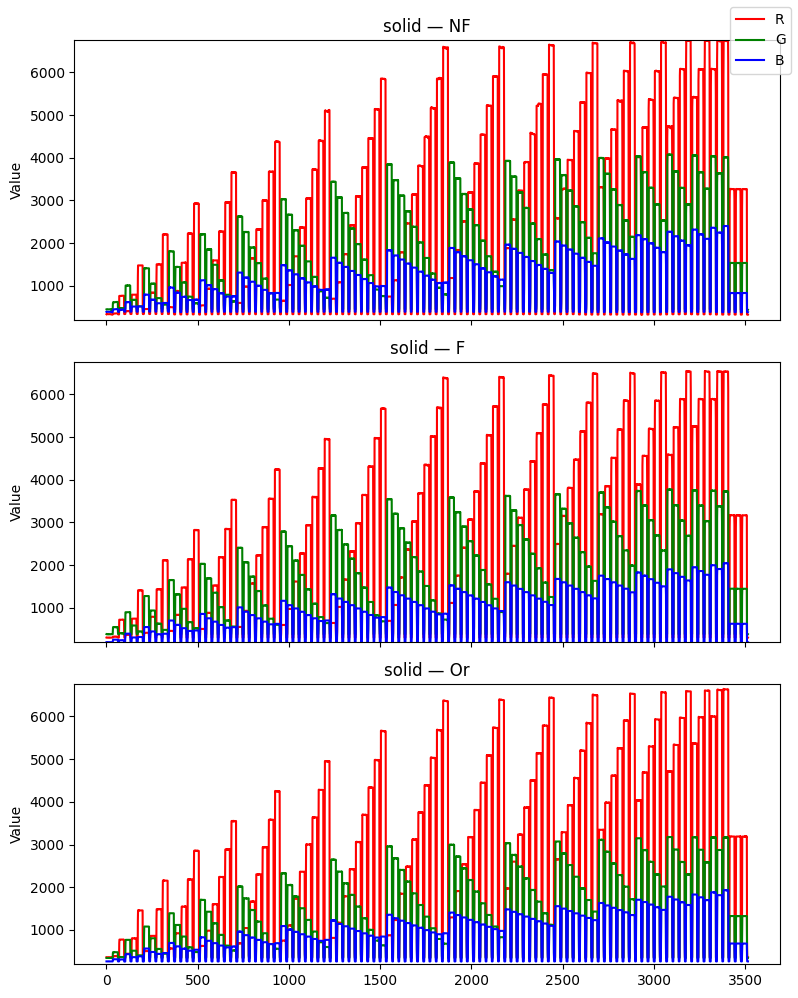

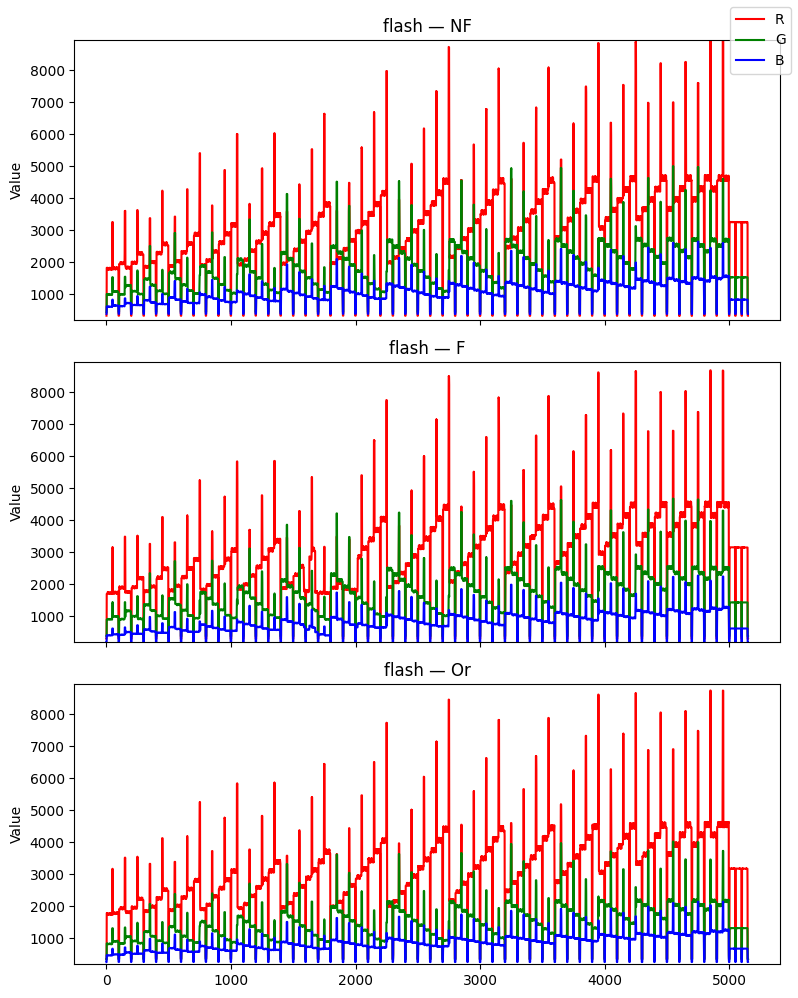

In [13]:
plot_condition_rgb(data, "solid")
plot_condition_rgb(data, "flash")

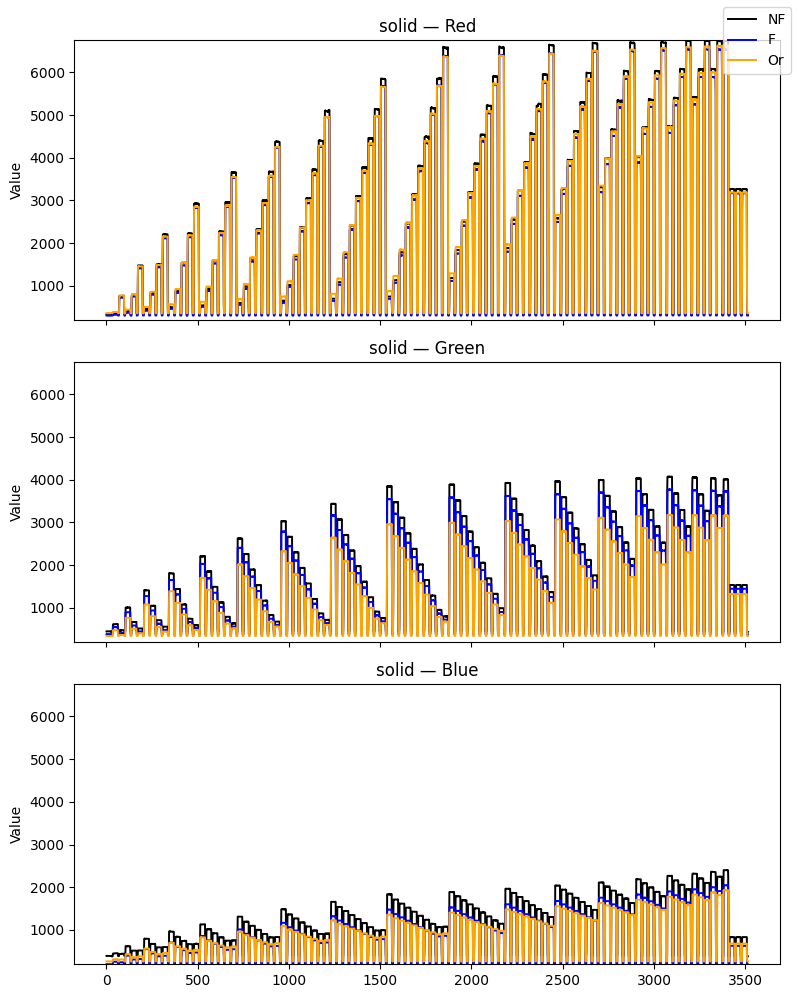

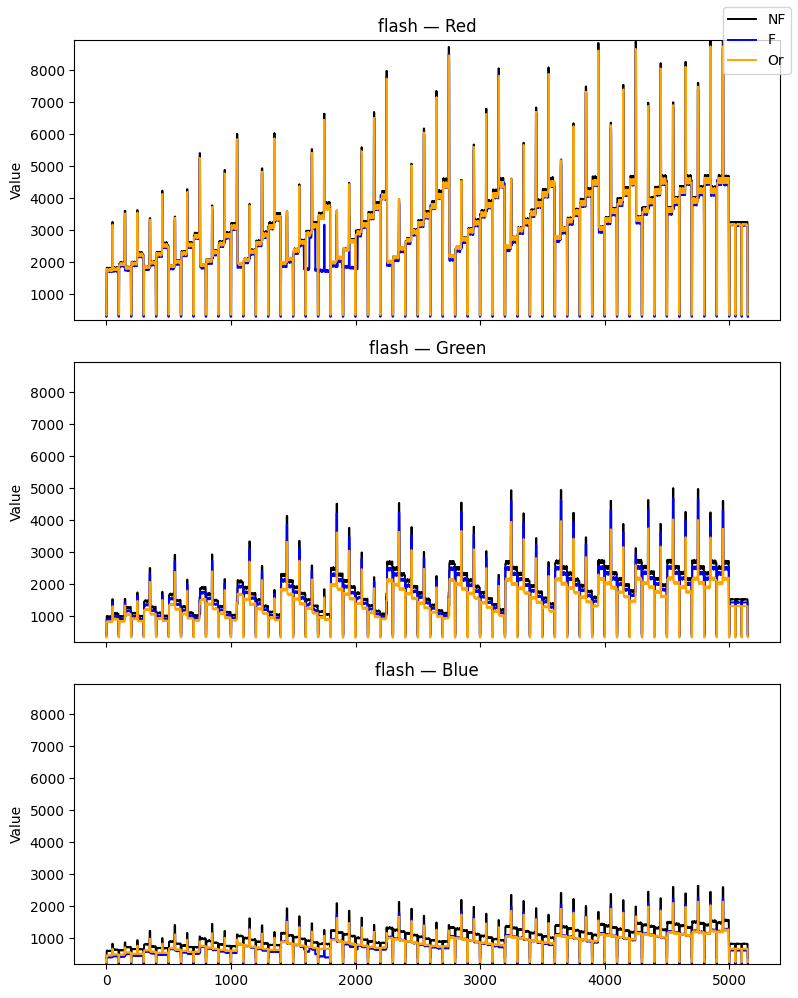

In [14]:
plot_condition_by_channel(data, "solid")
plot_condition_by_channel(data, "flash")